In [842]:
from MakeHam import *
from Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from SKQD import *
from PowerSampling import *
from CSRtoSPO import *
from BARK import *
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import tqdm
from scipy.sparse import csr_matrix
from qiskit.quantum_info import Operator
from qiskit.quantum_info import SparsePauliOp

In [843]:
# H = make_hermitian_sparse_random_from_qubits(8, 0.5)
H, psi = make_sparse_ground_state_hamiltonian_from_qubits(8, 200, ground_energy=-5, gap =1, add_excited_randomness=True, excited_random_strength=1)

# H = make_hermitian_sparse_random_from_qubits(8, 0.1)

In [844]:
H.shape

(256, 256)

In [845]:
op = Operator(H.toarray())

In [846]:
H_spo = SparsePauliOp.from_operator(op)

In [847]:
correct_energy, correct_state = eigsh(H, k=1, which='SA')

In [848]:
test_energy = eigsh(csr_matrix(H_spo.to_matrix()), k=1, which='SA')[0][0]
print(f"Correct energy: {correct_energy[0]}, SPO energy: {test_energy}")

Correct energy: -4.999999999998997, SPO energy: -5.000001286682194


In [849]:
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
sparsity = np.sum(amps > 1e-4) / len(amps)
print(f"Sparsity of the correct ground state: {sparsity:.4f}")

Sparsity of the correct ground state: 0.7695


In [850]:
print(np.argmax(amps))

70


In [851]:
np.argmax(amps)
n_steps = 16
initial = np.argmax(amps)

initial_state = np.zeros(H.shape[0])
initial_state[initial] = 1

In [852]:


# Print overlap with correct state
print(f"Initial overlap with correct state: {np.abs(np.dot(correct_state[:, 0].conj(), initial_state)):.4f}")

skqd_list0001 = do_skqd(H, n_steps, t = 0.001, initial=initial)
skqd_list001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list01 = do_skqd(H, n_steps, t = 0.1, initial=initial)
skqd_list02 = do_skqd(H, n_steps, t = 0.2, initial=initial)
skqd_list03 = do_skqd(H, n_steps, t = 0.3, initial=initial)
skqd_list04 = do_skqd(H, n_steps, t = 0.4, initial=initial)
skqd_list05 = do_skqd(H, n_steps, t = 0.5, initial=initial)
skqd_list06 = do_skqd(H, n_steps, t = 0.6, initial=initial)
skqd_list07 = do_skqd(H, n_steps, t = 0.7, initial=initial)
skqd_list08 = do_skqd(H, n_steps, t = 0.8, initial=initial)
skqd_list09 = do_skqd(H, n_steps, t = 0.9, initial=initial)
skqd_list10 = do_skqd(H, n_steps, t = 1.0, initial=initial)

Initial overlap with correct state: 0.1537


100%|██████████| 16/16 [00:00<00:00, 1369.32it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1279.58it/s]


No more indices left to sample.


...

No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 2077.80it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 965.08it/s]

No more indices left to sample.


In [853]:
skqd_path01 = get_one_path(H, skqd_list01)
skqd_path02 = get_one_path(H, skqd_list02)
skqd_path03 = get_one_path(H, skqd_list03)
skqd_path04 = get_one_path(H, skqd_list04)
skqd_path05 = get_one_path(H, skqd_list05)
skqd_path06 = get_one_path(H, skqd_list06)
skqd_path07 = get_one_path(H, skqd_list07)
skqd_path08 = get_one_path(H, skqd_list08)
skqd_path09 = get_one_path(H, skqd_list09)
skqd_path10 = get_one_path(H, skqd_list10)
skqd_path001 = get_one_path(H, skqd_list001)
skqd_path0001 = get_one_path(H, skqd_list0001)

In [854]:
#Convert initial state to string of 0 and 1 such that e.g 3 becomes 00000011
initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')[::-1]
BK = BARK(H_spo, initial_state=initial_bark, max_iterations=20, time_step=0.01, keep_states=20)

Converged at iteration 4


In [855]:
print([len(k) for k in BK.basis])

[1, 21, 148, 255, 256]


In [856]:
def flatten_unique(lists):
    result = []
    seen = set()
    
    for sublist in lists:
        for item in sublist:
            if item not in seen:
                seen.add(item)
                result.append(item)
    
    return result

In [857]:
def bitstrings_to_indices(basis: List[str]) -> List[int]:
    return [int(b, 2) for b in basis]

In [858]:
# Create one array from BK.basis by flattening it
BK_basis_flat = flatten_unique(BK.basis)

def get_one_path_from_BK(basis_list: List[str]) -> List[str]:
    energies = []
    for pos in tqdm.tqdm(range(len(basis_list))):
        current_basis = basis_list[:pos+1]
        indices = bitstrings_to_indices(current_basis)
        H_proj = project_down(H, indices)

        if pos > 2:
            energies.append(eigsh(H_proj, k=1, which='SA', return_eigenvectors=False)[0])
        else:
            energies.append(eigh(H_proj.toarray(), eigvals_only=True)[0])

    return energies

BK_path = get_one_path_from_BK(BK_basis_flat)

100%|██████████| 256/256 [00:02<00:00, 88.95it/s] 


## Bark 2.0

In [859]:
from Bark_2_0 import BarkBarkBark

In [860]:
initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')[::-1]
print(initial_bark)

01100010


In [ ]:
explorer = BarkBarkBark(
    H=H_spo,
    initial_state=initial_bark,
    keep_states=1,            # M
    max_applications=250,      # number of H-applications to selected batches
    mode="top_m",             # or "importance_sample"
    sample_size=1,           # only used for importance_sample
    sampling_score="amplitude",
    return_only_applied_bitstrings=True,
    random_seed=123,
)

bitstrings = explorer.run()
print(len(bitstrings))

print(bitstrings)

256
['01100010', '01001100', '01011000', '11010110', '11101101', '11000001', '11000111', '10100010', '10001001', '00011010', '11010001', '00001101', '01010110', '01000010', '01000111', '00100010', '01011101', '10101101', '10111001', '01101011', '11100110', '01011111', '10011010', '10001100', '01110101', '01010001', '11111111', '01101100', '10000010', '11011010', '00100101', '00101100', '00101010', '00100111', '10000001', '01010000', '11100001', '11011111', '00101110', '00001100', '00011111', '00001110', '00110001', '10111101', '01111001', '01001010', '11100100', '11110011', '11110000', '10001101', '11010000', '01110111', '10100001', '01111110', '10101001', '01000101', '11011100', '10000000', '01010111', '01000110', '11111000', '01010010', '11100011', '10100000', '11101010', '00000100', '10110001', '10100100', '01110011', '10010111', '11111100', '01100111', '01001011', '00101011', '10010110', '10100110', '01101001', '01101111', '01100011', '10111110', '10110010', '10110100', '00111100',

In [862]:
BK_BK_BK_path = get_one_path_from_BK(bitstrings)

100%|██████████| 256/256 [00:02<00:00, 86.49it/s] 


In [863]:
# assert False

In [864]:
power_list = do_power(H, n_steps, initial=initial)

100%|██████████| 16/16 [00:00<00:00, 1184.52it/s]

No more indices left to sample.


In [865]:
power_path = get_one_path(H, power_list)

In [866]:
Paths = get_all_paths(H, 100, initial)

Computing paths: 100%|██████████| 100/100 [04:16<00:00,  2.56s/it]


In [867]:
Paths.shape

(100, 256)

In [868]:
print(len(BK_BK_BK_path))

256


100


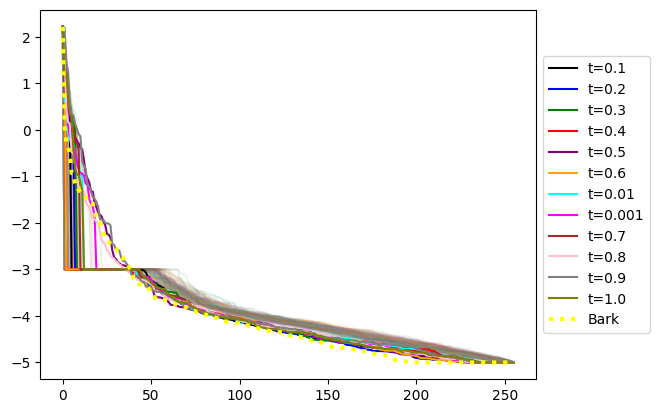

In [869]:
i = 0
for path in Paths:
    plt.plot(path, alpha=0.1)
    i += 1
plt.plot(skqd_path01, label='t=0.1', color='black')
plt.plot(skqd_path02, label='t=0.2', color='blue')
plt.plot(skqd_path03, label='t=0.3', color='green')
plt.plot(skqd_path04, label='t=0.4', color='red')
plt.plot(skqd_path05, label='t=0.5', color='purple')
plt.plot(skqd_path06, label='t=0.6', color='orange')
plt.plot(skqd_path001, label='t=0.01', color='cyan')
plt.plot(skqd_path0001, label='t=0.001', color='magenta')
plt.plot(skqd_path07, label='t=0.7', color='brown')
plt.plot(skqd_path08, label='t=0.8', color='pink')
plt.plot(skqd_path09, label='t=0.9', color='gray')
plt.plot(skqd_path10, label='t=1.0', color='olive')
# plt.plot(power_path, label='Power Sampling', color='purple', linestyle='dashed')
# plt.plot(BK_path, label='BARK', color='purple', linestyle='dotted')
plt.plot(BK_BK_BK_path, label='Bark', color='yellow',linewidth=3.0, linestyle='dotted')
# Make legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
print(i)

In [870]:
# for bigger nQ, it might get worse....